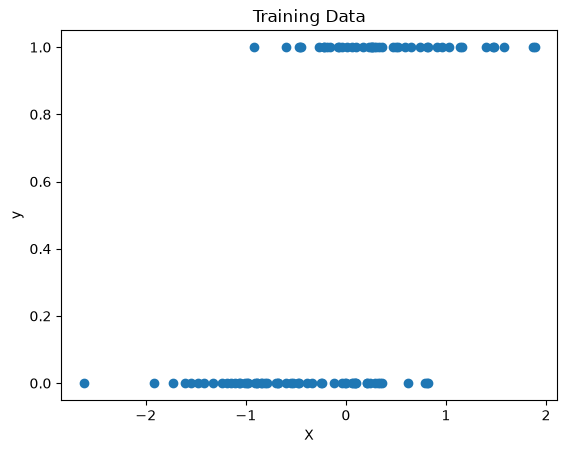

In [42]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.random.randn(100, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int).reshape(-1, 1)

plt.scatter(X[:, 0], y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Training Data')
plt.show()

In [43]:
# general sigmoid function
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [44]:
print(sigmoid(0))
print(sigmoid(50))
print(sigmoid(100))

0.5
1.0
1.0


In [45]:
def cost_func_logistic(X, y, theta):
    X_b = np.c_[np.ones((len(X), 1)), X] # add bias term
    m = len(y) # number of training examples
    Y_pred = sigmoid(np.matmul(X_b, theta))
    Y_pred = np.clip(Y_pred, 1e-10, 1 - 1e-10) # fix by clipping predictions to avoid log(0)
    mse = -1/m * np.sum(y * np.log(Y_pred) + (1 - y) * np.log(1 - Y_pred))
    return mse

In [46]:
theta = np.zeros((3,1))
print(cost_func_logistic(X, y, theta))

0.6931471805599453


In [47]:
def gradient_descent_logistic(X, y, theta, learning_rate, iterations):
    m = len(y)
    X_b = np.c_[np.ones((len(X), 1)), X]
    cost_history = []

    for i in range(iterations):
        Y_pred = sigmoid(np.matmul(X_b, theta))
        theta = theta - learning_rate * (1/m) * np.matmul(X_b.T, (Y_pred - y))
        cost_history.append(cost_func_logistic(X, y, theta))

    return theta, cost_history

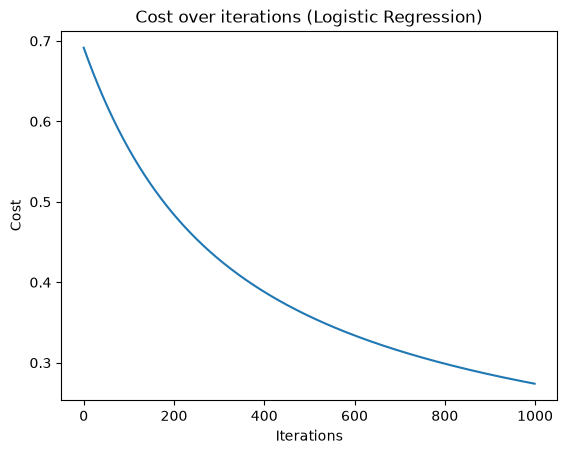

[[-0.19167336]
 [ 1.25661241]
 [ 1.40253888]]


In [48]:
theta = np.zeros((3,1))
theta, cost_history = gradient_descent_logistic(X, y, theta, 0.01, 1000)

plt.plot(cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost over iterations (Logistic Regression)')
plt.show()

print(theta)


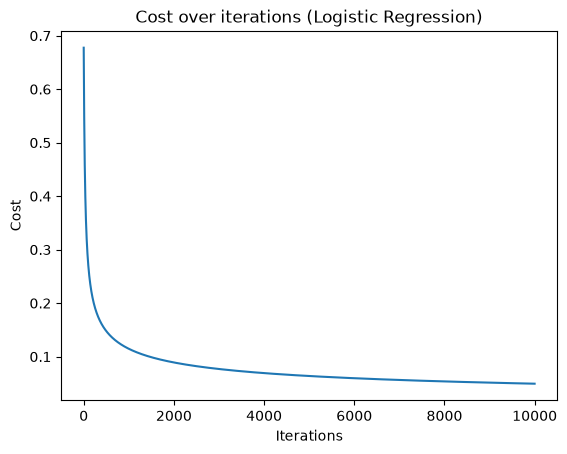

[[-0.15065898]
 [ 8.83734769]
 [ 8.46602431]]


In [49]:
# checking with learning_rate = 0.1 and iterations = 10000
theta = np.zeros((3,1))
theta, cost_history = gradient_descent_logistic(X, y, theta, 0.1, 10000)

plt.plot(cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost over iterations (Logistic Regression)')
plt.show()

print(theta)

In [50]:
# update theta with Newton's method
def newtons_method_logistic(X, y, theta, iterations):
    m = len(y)
    X_b = np.c_[np.ones((len(X), 1)), X]
    cost_history = []

    for i in range(iterations):
        Y_pred = sigmoid(np.matmul(X_b, theta))
        gradient = (1/m) * np.matmul(X_b.T, (Y_pred - y))
        # converting to diagonal matrix for Hessian calculation
        R = np.diag((Y_pred * (1-Y_pred)).flatten()) # (100,100)
        hessian = (1/m) * np.matmul(X_b.T, np.matmul(R, X_b))
        theta = theta - np.matmul(np.linalg.inv(hessian), gradient)
        cost_history.append(cost_func_logistic(X, y, theta))  

    return theta, cost_history

[[ -1.6126589 ]
 [282.65913615]
 [270.45246569]]


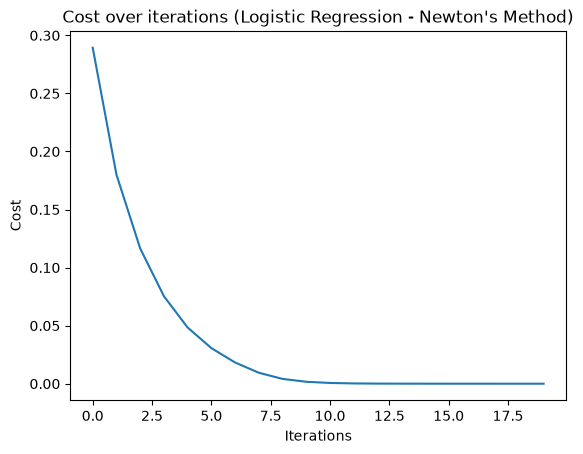

In [55]:
theta = np.zeros((3, 1))
theta, cost_history = newtons_method_logistic(X, y, theta, 20)
print(theta)

plt.plot(cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost over iterations (Logistic Regression - Newton\'s Method)')
plt.show()